## > run

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.metrics.cluster import adjusted_rand_score

## > run
Essas são as variáveis usadas para percorrer os timestamps:

- **minpts_max**: irá percorer de 2 até minpts -1, step 2 
- **local**: a pasta onde será salvo os resultados, é também o nome do dataset
- **ti**: imestamp inicial
- **tf**: timestamp final (acrescentar +1 por conta do FOR)

In [18]:
minpts_max = 201
local      = "kddcup"
ti         = 200
tf         = 1801
skip       = []

## > run
Aqui é onde cria a pasta automaticamente, será criada uma pasta com o nome que é colocado na variável **local**

m_directory = os.path.join(os.getcwd(), "results_corestream_hastream/" + str(local))
        
try:
    if not os.path.exists(m_directory):
        os.makedirs(m_directory)
        
except FileNotFoundError as e:
    print(e)

## > run

Pega apenas a coluna do ARI (os ARIs de ralação de cada minpts) de cada timestamp e coloca nas variáveis com posição de 1 até o número de timestamps:
- **df_mean_std_corestream**
- **df_mean_std_hastream**

In [19]:
df_mean_std_corestream = pd.DataFrame(index=[x for x in range(2, 201, 2)])
df_mean_std_hastream   = pd.DataFrame(index=[x for x in range(2, 201, 2)])

for t in range(ti, tf, ti):
    if t in skip:
        continue
    try:
        df_ari_corestream         = pd.read_csv("corestream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)
        df_mean_std_corestream[t] = df_ari_corestream['ARI']

        print(t)
        
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado.")
        
    try:
        df_ari_hastream         = pd.read_csv("hastream/results/" + local + "/flat_solutions/flat_solution_partitions_t" + str(t) + "/ARI_partitions.csv", sep=',', index_col=0)
        df_mean_std_hastream[t] = df_ari_hastream['ARI']

        print(t)
        
    except FileNotFoundError:
        print(f"Erro: O arquivo não foi encontrado.")

200
200
400
400
600
600
800
800
1000
1000
1200
1200
1400
1400
1600
1600
1800
1800


## > run
Gera o cráfico com a média e desvio padrão dos timestamps do CoreStream (em azul) e Hastream (em amarelo).

O ARI é a comparação das partições do CoreStream com o HDBSCAN e o Hastream com o HDBSCAN.

C:\Users\natan\AppData\Local\Temp\ipykernel_1516\4270948659.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo--" (-> color='b'). The keyword argument will take precedence.
  plt.plot(times_cor, mean_cor, 'bo--', color="blue", label='ARI Mean CoreStream', markersize=15)
C:\Users\natan\AppData\Local\Temp\ipykernel_1516\4270948659.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rs--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(times_has, mean_has, 'rs--', color="orange", label='ARI Mean HAStream', markersize=15)


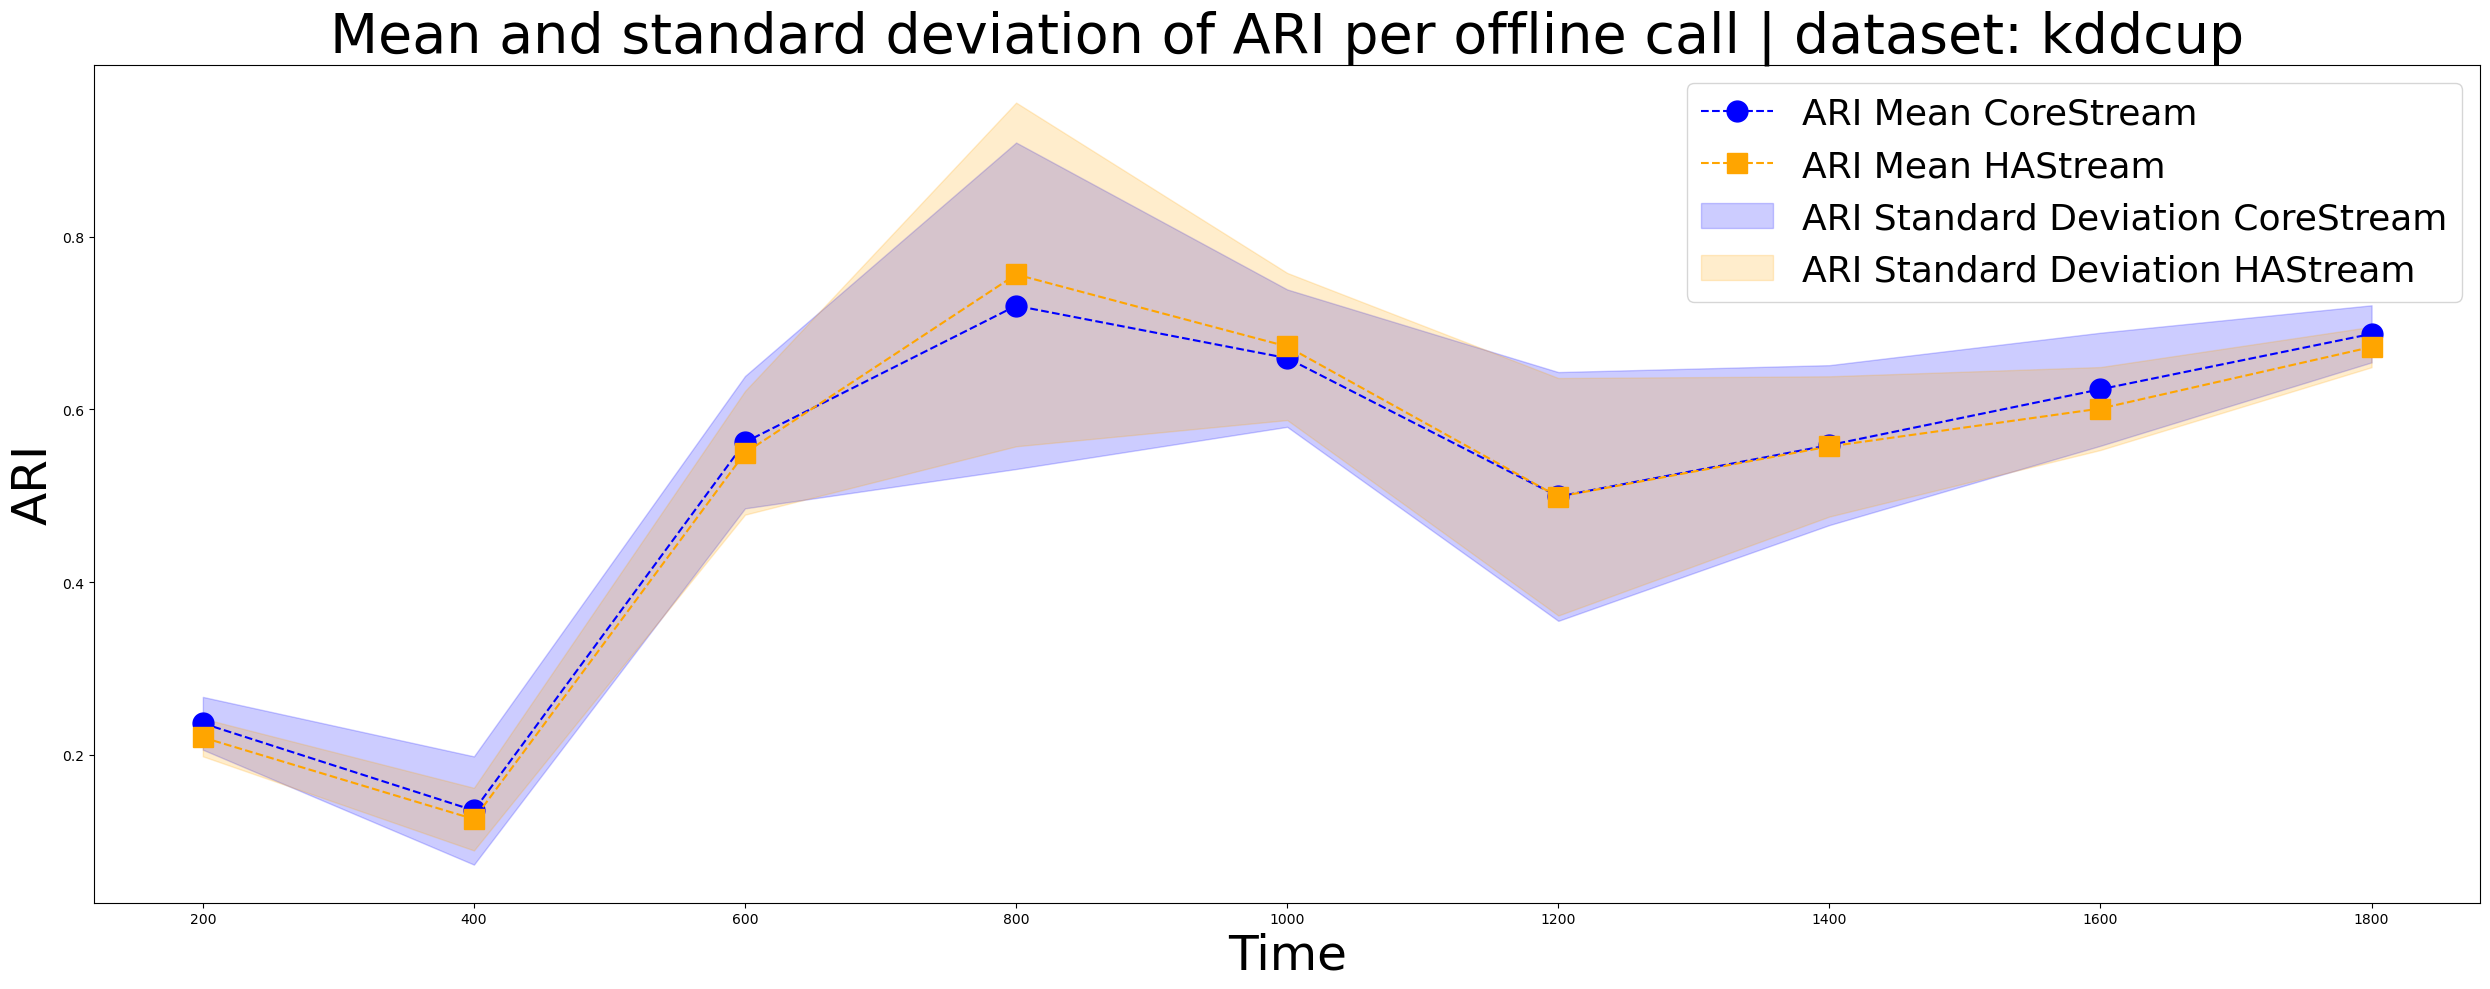

In [20]:
plt.figure(figsize = (25,10))
plt.title('Mean and standard deviation of ARI per offline call' + " | dataset: " + str(local), fontsize=40)

times_cor = df_mean_std_corestream.columns
times_has = df_mean_std_hastream.columns

mean_cor = df_mean_std_corestream.mean(axis=0)
std_cor  = df_mean_std_corestream.std(axis=0)

mean_has = df_mean_std_hastream.mean(axis=0)
std_has  = df_mean_std_hastream.std(axis=0)

plt.plot(times_cor, mean_cor, 'bo--', color="blue", label='ARI Mean CoreStream', markersize=15)
plt.plot(times_has, mean_has, 'rs--', color="orange", label='ARI Mean HAStream', markersize=15)
    
plt.fill_between(times_cor, (mean_cor - std_cor), (mean_cor + std_cor), color='blue', alpha=0.2, label='ARI Standard Deviation CoreStream')
plt.fill_between(times_has, (mean_has - std_has), (mean_has + std_has), color='orange', alpha=0.2, label='ARI Standard Deviation HAStream')
    
plt.xlabel("Time", fontsize=35)
plt.ylabel("ARI", fontsize=35)
plt.legend(fontsize="26")

plt.tight_layout()

plt.savefig("results_corestream_hastream/" + str(local) + "_ari_mean_std_resume_per_time.png")

#plt.close()

In [20]:
df_mean_std_corestream.columns

Int64Index([ 200,  400,  600,  800, 1000, 1200, 1400, 1600, 1800, 2000, 2200,
            2400, 2600, 2800, 3000, 3200, 3400, 3600, 3800, 4000, 4200, 4400,
            4600, 4800, 5000, 5200, 5400, 5600, 5800],
           dtype='int64')